Author: Julia Jurkowska

## Simulating and Localizing Multi-Source EEG Activity with MVPURE_py

This tutorial walks through a complete pipeline for simulating brain activity from multiple sources and evaluating source localization accuracy using **MVPURE_py** framework.

#### Introduction
This tutorial provides a comprehensive workflow for:
1. **Simulating realistic multi-source brain activity** using autoregressive models with controlled spatial and temporal characteristics.
2. **Forward modeling** to project cortical sources to sensor space through lead field matrices.
3. **Data processing** following standard EEG pipelines to prepare signals for inverse modeling.
4. **Source localization** using **MVPURE_py** and LCMV-NAI.
5. **Quantitative evaluation** of localization accuracy.

Controlled simulations are essential for validating inverse solutions because they provide:
- **Ground truth**: we know exactly where and when activity occurs.
- **Parameter control**: we can systematically vary SNR, source configuration and coupling.

This tutorial uses the **MVPURE_py** package, which extends MNE-Python with tools for multivariate source analysis.

#### Tutorial overview
We will:
- Load anatomical and forward model data for ``sample_subject`` (downloadable from [Figshare](https://figshare.com/articles/dataset/Sample_subject_data_/30102451?file=57853861))
- Define regions of interest (ROIs) using Desikan-Killiany parcellation
- Generate synthetic source time courses with configurable temporal dynamics
- Project cortical activity to EEG sensor space via the forward solution
- Add controlled sensor noise and apply standard preprocessing
- Localize and reconstruct sources using **MVPURE_py** and LCMV beamforming
- Quantify localization error

In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt

import os

mne.viz.set_3d_backend('pyvistaqt')

from mvpure_py import viz, utils, simulation

Using pyvistaqt 3d backend.


### Simulation Configuration

#### Anatomical labeling and source selection
We define simulation parameters that control both the spatial distribution and temporal characteristics of simulated brain activity. The workflow distinguishes between two types of sources:

1. **Task-related activity** (post-stimulus): Simulated cortical responses following stimulus onset
2. **Background activity**: Ongoing oscillatory and coupled activity present throughout the recording

Source locations are specified using the Desikan-Killiany ``aparc`` parcellation atlas. 

#### Temporal dynamics parameters
The simulation uses Multivariate AutoRegressive (MVAR) models to generate temporally structured source activity. Key parameters include:

- **MVAR order** (``ORDER``, ``ORDER_BG``): Determines temporal memory of the autoregressive process. Higher orders capture longer-range temporal dependencies but increase model complexity.

- **Coupling strength** (``COUPLING``, ``COUPLING_BG``): Controls cross-source interactions in the MVAR model. Values near 0 produce independent sources; values near 1 create strong interdependencies. Physiologically, this reflects effective connectivity between regions.

- **Innovation noise** (``NOISE``, ``NOISE_BG``): Amplitude of the white noise innovations driving the MVAR process. This controls the stochasticity vs. deterministic structure in the generated signals.

- **Temporal smoothing** (``GAUSSIAN_FILTER_SIGMA``, ``GAUSSIAN_FILTER_SIGMA_BG``): Standard deviation of Gaussian kernel applied to smooth generated time courses. This removes high-frequency artifacts and produces more physiologically realistic signals.

#### Signal amplitude and SNR control

- **Target standard deviation** (``TARGET_STD``, ``TARGET_STD_BG``): Sets the amplitude of source activity in Ampere-meters (Am).

- **ERP scaling factor** (``ERP_FACTOR``): Amplitude multiplier for event-related potential (ERP) components. This controls the strength of phase-locked, stimulus-evoked responses relative to ongoing activity.

- **SNR** (``SNR_DB``): Signal-to-noise ratio in decibels on source level.

- **Sensor noise factor** (``NOISE_FACTOR_SENSORS``): Additional amplitude scaling for sensor-level noise, allowing independent control of source-level and measurement noise.

#### Dataset size

- **Number of epochs** (``N_EPOCHS``): Determines statistical power for covariance estimation. More epochs provide more stable covariance estimates, improving beamformer performance.

- **Vertices per region** (``N_VERTICES_PER_ACTIVITY_LABEL``, ``N_VERTICES_PER_BG_LABEL``): Controls spatial extent of activity within each ROI.

These parameters collectively define a realistic but controlled simulation environment. For methodological studies, parameters can be systematically varied to characterize performance across different scenarios.

For more details see [paper](https://arxiv.org/pdf/2509.14118).

In [2]:
labels_to_use = [
    "cuneus-lh",
    "cuneus-rh",
    "lateraloccipital-lh",
    "lateraloccipital-rh",
    "inferiorparietal-lh",
    "inferiorparietal-rh",
    "superiorparietal-lh",
    "superiorparietal-rh",
    "superiortemporal-lh",
    "superiortemporal-rh",
    "supramarginal-lh",
    "supramarginal-rh",
    "superiorfrontal-lh",
    "superiorfrontal-rh",
    "insula-lh",
    "insula-rh",
    "caudalanteriorcingulate-lh",
    "caudalanteriorcingulate-rh"
]

labels_to_use_poststimuli = [
    "cuneus-lh",
    "cuneus-rh",
    "lateraloccipital-lh",
    "lateraloccipital-rh",
    "inferiorparietal-lh",
    "inferiorparietal-rh",
]

In [3]:
N_VERTICES_PER_BG_LABEL = 1
N_VERTICES_PER_ACTIVITY_LABEL = 1
N_EPOCHS = 100
SNR_DB = 1.0
ERP_FACTOR = 15e-9
ORDER_BG = 7
ORDER = 3
TARGET_STD_BG = 15e-9  
TARGET_STD = 15e-9
COUPLING_BG = 0.5
COUPLING = 0.8
NOISE_BG = 1.0
NOISE = 1.0 
GAUSSIAN_FILTER_SIGMA_BG = 3
GAUSSIAN_FILTER_SIGMA = 3
N_DOMINANT_EIGVALS = 2
NOISE_FACTOR_SENSORS = 0.3

### Loading real data for sample subject
We load:
- **Epoched EEG data**: Used here only to extract metadata (sampling rate, time windows, channel names)
- **Forward solution**: Contains the lead field matrix and source space geometry

The forward solution has already been converted to **fixed orientation** (surface-normal constraint), which reduces degrees of freedom from 3 to 1 per source location.

In [4]:
# Reading real data for sample subject
subject = "sample_subject"
subjects_dir = "subjects"
mne.set_config('SUBJECTS_DIR', subjects_dir)

epoched = mne.read_epochs(os.path.join(subjects_dir, subject, "_eeg", "_pre", f"{subject}_oddball-epo.fif"))

# Read forward
forward_path = os.path.join(subjects_dir, subject, "forward", f"{subject}_ico4-fwd.fif")
fwd_vector = mne.read_forward_solution(forward_path)
fwd = mne.convert_forward_solution(
    fwd_vector,
    surf_ori=True,
    force_fixed=True,
    use_cps=True
)

# Leadfield matrix
leadfield = fwd["sol"]["data"]

# Source positions extracted from forward model
src = fwd["src"]

Reading /Volumes/UMK/oddball/subjects/sample_subject/_eeg/_pre/sample_subject_oddball-epo.fif ...
    Found the data of interest:
        t =    -199.22 ...     800.78 ms
        0 CTF compensation matrices available
Not setting metadata
621 matching events found
No baseline correction applied
0 projection items activated
Reading forward solution from /Volumes/UMK/oddball/subjects/sample_subject/forward/sample_subject_ico4-fwd.fif...
    Reading a source space...
    [done]
    Reading a source space...
    [done]
    2 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read EEG forward solution (5124 sources, 128 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
    No patch info available. The standard source space normals will be employed in the rotation to the local surface coordinates....
    Changing to fixed-orientation forward solution with surface-based source orientatio

We extract key timing parameters:
- sampling frequency (``sfreq``)
- time window (``tmin`` to ``tmax``)
- time vector (``times``) with its mask corresponding to sensory processing activity during oddball paradigm (``post_mask``)

In [5]:
sfreq = epoched.info['sfreq']
tmin, tmax = epoched.tmin, 0.25
tmin_sensory = 0.05
tmax_sensory = 0.2
times = np.arange(tmin, tmax, 1/sfreq)
n_times = len(times)

post_mask = (times >= tmin_sensory) & (times <= tmax_sensory)

### Generating source locations
Rather than activating entire anatomical regions uniformly, we randomly select individual vertices within each label. 
For this simulation:
- **Background sources**: Selected from the full ``labels_to_use`` set (18 bilateral regions)
- **Task-related sources**: Selected from ``labels_to_use_poststimuli`` (6 posterior regions)

This configuration mimics an oddball paradigm where visual stimuli engage posterior sensory areas while a broader network maintains sustained attention.

In [6]:
labels_info = simulation.get_random_vertices(
    n_vertices_per_label_bg=N_VERTICES_PER_BG_LABEL,
    n_vertices_per_poststimuli_label=N_VERTICES_PER_ACTIVITY_LABEL,
    all_labels=labels_to_use,
    poststimuli_labels=labels_to_use_poststimuli,
    subject=subject,
    subjects_dir=subjects_dir,
    src=src,
)
all_vertices, poststimuli_vertices = simulation.split_vertices(labels_info, labels_to_use_poststimuli)

# Mapping to leadfield space
leadfield_subset_indices, lh_vert_to_lf, rh_vert_to_lf = utils.translation.transform_vertices_to_leadfield_indices(
    vertices=all_vertices,
    src=src,
    hemi="both",
    include_mapping = True
)

leadfield_subset_poststimuli_indices = utils.translation.transform_vertices_to_leadfield_indices(
    vertices=poststimuli_vertices,
    src=src,
    hemi="both"
)

leadfield_to_label_mapping  = simulation.assign_label_to_leadfield_index(
    labels_info=labels_info,
    lh_vert_to_lf=lh_vert_to_lf,
    rh_vert_to_lf=rh_vert_to_lf
)

Reading labels from parcellation...
   read 0 labels from /Volumes/UMK/oddball/subjects/sample_subject/label/lh.aparc.annot
   read 1 labels from /Volumes/UMK/oddball/subjects/sample_subject/label/rh.aparc.annot
Reading labels from parcellation...
   read 1 labels from /Volumes/UMK/oddball/subjects/sample_subject/label/lh.aparc.annot
   read 0 labels from /Volumes/UMK/oddball/subjects/sample_subject/label/rh.aparc.annot
Reading labels from parcellation...
   read 0 labels from /Volumes/UMK/oddball/subjects/sample_subject/label/lh.aparc.annot
   read 1 labels from /Volumes/UMK/oddball/subjects/sample_subject/label/rh.aparc.annot
Reading labels from parcellation...
   read 1 labels from /Volumes/UMK/oddball/subjects/sample_subject/label/lh.aparc.annot
   read 0 labels from /Volumes/UMK/oddball/subjects/sample_subject/label/rh.aparc.annot
Reading labels from parcellation...
   read 1 labels from /Volumes/UMK/oddball/subjects/sample_subject/label/lh.aparc.annot
   read 0 labels from /Volum

### Simulating source activity
Now we generate synthetic source time series.
Our simulation generates two activity components:

**1. Background activity (entire epoch)**
- Higher MVAR order (``ORDER_BG`` = 7): Captures slower oscillatory dynamics
- Moderate coupling (``COUPLING_BG`` = 0.5): Weak to moderate inter-regional interactions
- Active throughout the epoch: Represents ongoing brain state

**2. Task-related activity (post-stimulus)**
- Lower MVAR order (``ORDER`` = 3): Transient, event-related dynamics  
- Strong coupling (``COUPLING`` = 0.8): Coordinated network response
- Restricted to post-stimulus period: Evoked sensory processing
- Includes ERP component: Phase-locked response to stimulus onset

After MVAR generation:
1. **Gaussian smoothing**: Reduces high-frequency noise, mimics dendritic integration
2. **Amplitude scaling**: Normalizes to target RMS amplitude (``TARGET_STD``)
3. **ERP addition**: Superimposes stereotyped waveform for evoked components

This yields ``n_epochs × n_sources × n_times`` array of source time courses with realistic spatiotemporal structure.

In [7]:
X_epochs = simulation.simulate_source_epochs(
    n_epochs=N_EPOCHS,
    lf_subset_indices=leadfield_subset_indices,
    n_times=n_times,
    poststimuli_mask=post_mask,
    poststimuli_lf_subset_indices=leadfield_subset_poststimuli_indices,
    lf_to_label=leadfield_to_label_mapping,
    sfreq=sfreq,
    erp_factor=ERP_FACTOR,
    snr_db=SNR_DB,
    order_bg=ORDER_BG,
    order=ORDER,
    target_std_bg=TARGET_STD_BG,
    target_std=TARGET_STD,
    coupling_bg=COUPLING_BG,
    coupling=COUPLING,
    noise_bg=NOISE_BG,
    noise=NOISE,
    n_dominant_eigvals=N_DOMINANT_EIGVALS,
    seed=42
)

### Projecting to sensor space

Source activity is projected to EEG electrodes using the forward solution. The simulated sensor data is packaged into an MNE ``Epochs`` object. This allows the simulated data to be processed identically to real recordings.

In [8]:
sim_epochs = simulation.simulate_sensor_epochs(
    X_epochs=X_epochs,
    leadfield=leadfield,
    lf_subset_indices=leadfield_subset_indices,
    src=src,
    tmin=tmin,
    sfreq=sfreq,
    noise_factor=NOISE_FACTOR_SENSORS,
    info=epoched.info
)
# sim_epochs.plot()

### Preprocessing

We apply basic preprocessing:

In [9]:
sim_epochs = sim_epochs.filter(l_freq=1, h_freq=45, method="iir")
# sim_epochs.plot()

Setting up band-pass filter from 1 - 45 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 1.00, 45.00 Hz: -6.02, -6.02 dB


Then re-reference the data:

In [10]:
sim_epochs_ref = sim_epochs.set_eeg_reference('average', projection=True)
sim_epochs_ref.apply_proj()

EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...


<EpochsArray | 100 events (all good), -0.199 – 0.246 s (baseline off), ~11.4 MiB, data loaded,
 '1': 100>

This mimics standard EEG preprocessing pipelines.

### Creating ground truth source estimates

We construct source estimated (``stc``) corresponding to simulated activity:

In [11]:
sim_stc = simulation.add_simulated_epochs_to_stc(
    X_epochs=X_epochs,
    src=src,
    n_times=n_times,
    lf_subset_indices=leadfield_subset_indices,
    tmin=tmin,
    sfreq=sfreq,
    subject=subject
)

# sim_stc.plot(hemi="both")

This serves as **ground truth** for later evaluation.

### Localization Pipeline

#### Covariance estimation
We compute noise and data covariance matrices as these are essential inputs for beamforming.

In [12]:
noise_cov = mne.compute_covariance(
    sim_epochs,
    tmin=-0.2,
    tmax=0,
    method="empirical"
)

data_cov = mne.compute_covariance(
    sim_epochs,
    tmin=0.05,
    tmax=0.2,
    method="empirical"
)

sim_evoked = sim_epochs.average()
# Subset signal for given time range
signal_sim = sim_evoked.crop(
    tmin=0.05,
    tmax=0.2
)

    Created an SSP operator (subspace dimension = 1)
    Setting small EEG eigenvalues to zero (without PCA)
Reducing data rank from 128 -> 127
Estimating covariance using EMPIRICAL
Done.
Number of samples used : 5200
[done]
    Created an SSP operator (subspace dimension = 1)
    Setting small EEG eigenvalues to zero (without PCA)
Reducing data rank from 128 -> 127
Estimating covariance using EMPIRICAL
Done.
Number of samples used : 3900
[done]


In [13]:
# Optional visualization

# signal_sim.plot()
# plt.show()

#### Eigenvalue spectrum visualization
The eigenvalue spectrum of the whitened data covariance reveals the signal subspace structure:
- Large eigenvalues: Capture coherent brain signals
- Small eigenvalues: Dominated by noise

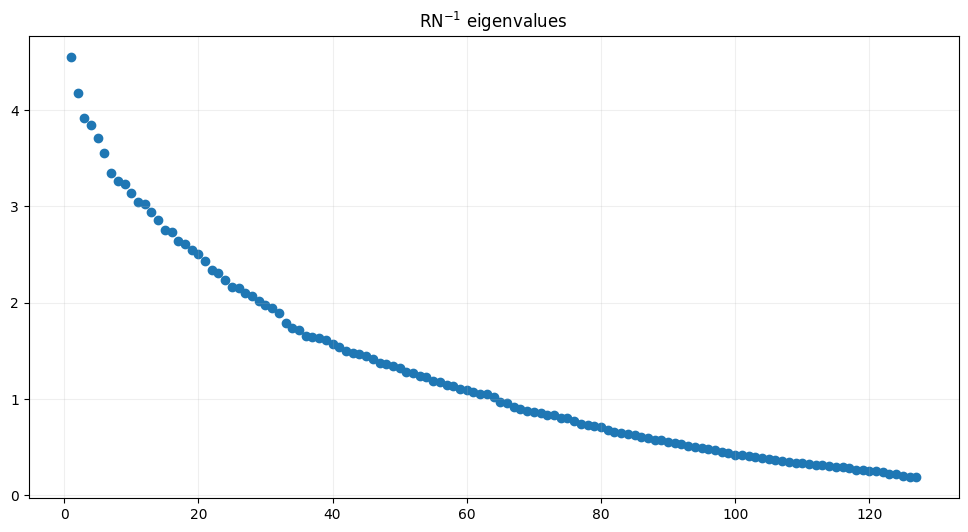

In [14]:
viz.plot_RN_eigenvalues(
    R=data_cov.data,
    N=noise_cov.data
)
plt.show()

#### Localization across ranks

We systematically evaluate beamformer performance for different rank values (1 to ``n_sources``). For each rank, we:

1. Construct rank-**k** localizer.
2. Compute localization metrics:
    - number of correctly localized sources,
    - distance error 


Calculating activity index for localizer: mai_mvp

[Activity Index Result]
  Selected indices (index_max): [3175, 274, 2615, 3021, 2374, 2849]
  Index max values: [0.78577935 1.13425896 1.37318353 1.44308371 1.513192   1.55822522]
  Rank parameter (r): 1
Calculating activity index for localizer: mai_mvp

[Activity Index Result]
  Selected indices (index_max): [3175, 274, 591, 2615, 232, 3044]
  Index max values: [0.78577935 1.55943631 1.86723207 2.17715898 2.46342582 2.77347779]
  Rank parameter (r): 2
Calculating activity index for localizer: mai_mvp

[Activity Index Result]
  Selected indices (index_max): [3175, 274, 591, 232, 3044, 2615]
  Index max values: [0.78577935 1.55943631 2.273855   2.62293093 2.97420034 3.33708565]
  Rank parameter (r): 3
Calculating activity index for localizer: mai_mvp

[Activity Index Result]
  Selected indices (index_max): [3175, 274, 591, 232, 3044, 2615]
  Index max values: [0.78577935 1.55943631 2.273855   3.0273721  3.46484468 3.83430257]
  Rank par

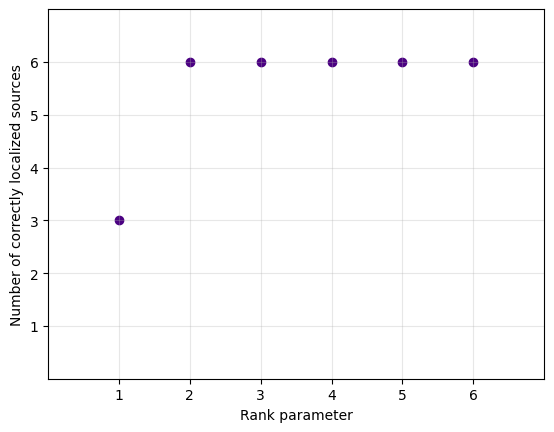

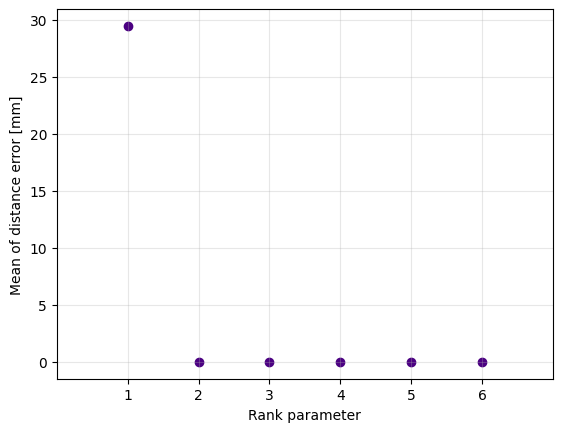

In [15]:
locs_results_summary = simulation.evaluate_localization_for_each_rank(
    subject=subject,
    subjects_dir=subjects_dir,
    n_sources=len(labels_to_use_poststimuli)*N_VERTICES_PER_ACTIVITY_LABEL,
    R=data_cov.data,
    N=noise_cov.data,
    forward=fwd,
    true_vertices=poststimuli_vertices,
    localizer_to_use="mai_mvp",
    plot_sum_error_by_rank=False,
    plot_correct_sources_by_rank=True,
    show_progress=False
)

### Standard LCMV Beamformer (for comparison)

For comparison with the rank-reduced MVPURE approach, we can also apply MNE's standard LCMV beamformer using ``mne.beamformer.make_lcmv``. Strongest sources are identified based on peak NAI value.

In [16]:
(
    lcmv_top_vertices,
    lcmv_n_correctly_localized,
    lcmv_error_info
) = simulation.compare_with_strongest_sources_lcmv(
    signal=sim_evoked,
    n_sources=len(labels_to_use_poststimuli)*N_VERTICES_PER_ACTIVITY_LABEL,
    true_vertices=poststimuli_vertices,
    forward=fwd,
    R=data_cov,
    N=noise_cov,
    reg=0.05,
    pick_ori=None
)

Computing rank from covariance with rank=None
    Using tolerance 5.1e-13 (2.2e-16 eps * 128 dim * 18  max singular value)
    Estimated rank (eeg): 127
    EEG: rank 127 computed from 128 data channels with 1 projector
Computing rank from covariance with rank=None
    Using tolerance 2.3e-13 (2.2e-16 eps * 128 dim * 8.2  max singular value)
    Estimated rank (eeg): 127
    EEG: rank 127 computed from 128 data channels with 1 projector
Making LCMV beamformer with rank {'eeg': 127}
Computing inverse operator with 128 channels.
    128 out of 128 channels remain after picking
Selected 128 channels
Whitening the forward solution.
    Created an SSP operator (subspace dimension = 1)
Computing rank from covariance with rank={'eeg': 127}
    Setting small EEG eigenvalues to zero (without PCA)
Creating the source covariance matrix
Adjusting source covariance matrix.
Computing beamformer filters for 5124 sources
Filter computation complete


In [17]:
print(f"Number of correctly localized sources using LCMV-NAI: {lcmv_n_correctly_localized}")
print(f"Mean distance error using LCMV-NAI: {np.round(lcmv_error_info['mean_error'], 2)} mm")

Number of correctly localized sources using LCMV-NAI: 3
Mean distance error using LCMV-NAI: 16.52 mm


This tutorial has shown a complete pipeline for:

1. **Simulating realistic EEG data** with known ground truth sources
2. **Controlling experimental parameters** (SNR, coupling, spatial distribution)
3. **Preprocessing** sensor data using standard pipelines
4. **Applying localization algorithm** with the MVPURE framework
5. **Quantitatively evaluating** localization performance.

To further explore source localization: test different SNRs, coupling strengths, or source configurations.